# Prezzo telefoni

> Data: **2025-11-21**
>
> Autore: **Luigi Malaguti**

##

---

## Parte 0: Il Dataset

Il dataset (preso da [Kaggle](https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification)) contiene dati relativi ad alcuni cellulari. Il dataset contiene diverse feature descritte di seguito, si vuole predire il valore di range di prezzo sulla base degli attributi presenti nel dataset:

- battery_power: potenza della batteria (mAh)
- blue: ha il bluetooth oppure no (boolean)
- clock_speed: velocità del microprocessore
- dual_sim: ha il supporto dual sim oppure no (boolean)
- fc: mega pixels della telecamera frontale
- four_g: ha il 4G oppure no (boolean)
- int_memory: nemoria interna (GB)
- m_dep: Mobile Depth (cm)
- mobile_wt: peso
- n_cores: numero di core del processore
- pc: mega pixels della fotocamera esterna
- px_height: Pixel Resolution Height
- px_width: Pixel Resolution Width
- ram: RAM (MB)
- sc_h: altezza schermo (cm)
- sc_w: larghezza schermo (cm)
- talk_time: durata massima della batteria
- three_g: ha il 3G oppure no (boolean)
- touch_screen: ha il touch screen oppure no (boolean)
- wifi: ha il wifi oppure no (boolean)
- price_range: colonna target con valori 0 (costo basso), 1 (costo medio), 2 (costo alto), 3 (costo molto alto)

### Imports

In [ ]:
!curl -sLo dataset.zip "https://www.kaggle.com/api/v1/datasets/download/iabhishekofficial/mobile-price-classification"
!unzip -o dataset.zip
!mv train.csv dataset.csv
# FILE_ID = "file_id"
# !curl -sLo dataset.csv "https://drive.google.com/uc?export=download&id={FILE_ID}"

Archive:  dataset.zip
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import FeatureUnion

### Dataset

In [ ]:
df = pd.read_csv("dataset.csv")

#### Overview

In [ ]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

#### Instances

In [ ]:
df.shape

(2000, 21)

#### Missing values

In [ ]:
df.isnull().sum().sum()

np.int64(0)

#### Balancing

In [ ]:
df["price_range"].value_counts()

,count
price_range,
1,500
2,500
3,500
0,500


<Axes: >

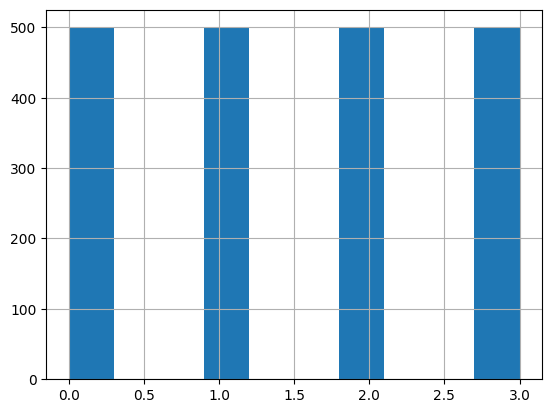

In [ ]:
df["price_range"].hist()

##

---

## Parte 2: Trasformazione e Predizione

### Domanda 01

Creare una pipeline in cui gli attributi `int_memory`, `ram` e `talk_time` sono scalati in modo che abbiano media 0 e varianza 1, gli attributi `mobile_wt` e `battery_power` sono discretizzati in 5 intervalli, e **tutti gli altri attributi sono lasciati invariati**. La pipeline deve applicare il modello DecisionTree. Valutare l’accuratezza della classificazione attraverso accuracy e confusion matrix.

In [ ]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [ ]:
X, y = df.drop("price_range", axis=1), df["price_range"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=123, stratify=y)

In [ ]:
scaler = StandardScaler()
discretized = KBinsDiscretizer(n_bins=5)

column_transformer = ColumnTransformer(
    transformers=[
        ("scaler", scaler, ["int_memory", "ram", "talk_time"]),
        ("discretized", discretized, ["mobile_wt", "battery_power"]),
    ],
    remainder="passthrough",
)
column_transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('scaler', StandardScaler(),
                                 ['int_memory', 'ram', 'talk_time']),
                                ('discretized', KBinsDiscretizer(),
                                 ['mobile_wt', 'battery_power'])])

In [ ]:
decision_tree = DecisionTreeClassifier(random_state=123)

pipeline = Pipeline(
    steps=[
        ("column_transformer", column_transformer),
        ("decision_tree", decision_tree)
    ],
)
pipeline

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['int_memory', 'ram',
                                                   'talk_time']),
                                                 ('discretized',
                                                  KBinsDiscretizer(),
                                                  ['mobile_wt',
                                                   'battery_power'])])),
                ('decision_tree', DecisionTreeClassifier(random_state=123))])

In [ ]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred, average="weighted"))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.788
F1: 0.788961501909663
[[108  17   0   0]
 [ 15  93  17   0]
 [  0  22  88  15]
 [  0   0  20 105]]


> Dalle metriche valutate possiamo notare come la pipeline abbia una discreta accuratezza, quasi 80% considerando anche la metrica F1, e dalla confusion matrix possiamo notare come non ci sono particolari valori su cui la pipeline commette maggiormente errori.

---

### Domanda 02

Aggiungere alla pipeline del punto 1 la funzione SelectKBest per selezionare K feature tra quelle restituite dalla pipeline del punto 1. Utilizzare la funzione di **gridSearchCV** per selezionare il valore migliore di `K`, il numero migliore di bin in cui discretizzare i valori di `mobile_wt` e `battery_power` e i valori degli iperparametri `criterion` e `min_samples_leaf` del modello DecisionTree (scegliere a piacere alcuni valori).

In [ ]:
k_best = SelectKBest()

pipeline = Pipeline(
    steps=[
        ("column_transformer", column_transformer),
        ("k_best", k_best),
        ("decision_tree", decision_tree),
    ],
)
pipeline

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('column_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['int_memory', 'ram',
                                                   'talk_time']),
                                                 ('discretized',
                                                  KBinsDiscretizer(),
                                                  ['mobile_wt',
                                                   'battery_power'])])),
                ('k_best', SelectKBest()),
                ('decision_tree', DecisionTreeClassifier(random_state=123))])

In [ ]:
params = {
    "column_transformer__discretized__n_bins": [5, 10, 15],
    "k_best__k": [5, 10, 15],
    "decision_tree__criterion": ["gini", "entropy", "log_loss"],
    "decision_tree__min_samples_leaf": [1, 2, 3, 4, 5],
}
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred, average="weighted"))
print(confusion_matrix(y_test, y_pred))

Best params: {'column_transformer__discretized__n_bins': 5, 'decision_tree__criterion': 'entropy', 'decision_tree__min_samples_leaf': 4, 'k_best__k': 10}
Best score: 0.8513333333333332
Accuracy: 0.838
F1: 0.8382817096071217
[[116   9   0   0]
 [ 12 106   7   0]
 [  0  23  93   9]
 [  0   0  21 104]]


> Possiamo notare che i parametri migliori ottenuti sono i seguenti:
>
> - `n_bins`: 5
> - `criterion`: 'entropy'
> - `min_samples_leaf`: 4
> - `k`: 10
>
> Mentre per quanto riguarda le performance, grazie ai parametri ottimali, la pipeline è migliorato i propri punteggi di 3-4 punti percentuali.

---

### Domanda 03

Creare una nuova pipeline che applica la decomposizione TruncatedSVD al dataset iniziale e **aggiunge le componenti** ottenute alla pipeline del punto 1. Valutare il valore migliore per il numero di componenti di TruncatedSVD tra 2, 4 e 6.

In [ ]:
df = pd.read_csv("dataset.csv")
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [ ]:
X, y = df.drop("price_range", axis=1), df["price_range"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=123, stratify=y)

In [ ]:
truncated_svd = TruncatedSVD(random_state=123)

feature_union = FeatureUnion(
    transformer_list=[
        ("truncated_svd", truncated_svd),
        ("column_transformer", column_transformer),
    ],
)
feature_union

FeatureUnion(transformer_list=[('truncated_svd',
                                TruncatedSVD(random_state=123)),
                               ('column_transformer',
                                ColumnTransformer(remainder='passthrough',
                                                  transformers=[('scaler',
                                                                 StandardScaler(),
                                                                 ['int_memory',
                                                                  'ram',
                                                                  'talk_time']),
                                                                ('discretized',
                                                                 KBinsDiscretizer(),
                                                                 ['mobile_wt',
                                                                  'battery_power'])]))])

In [ ]:
best_criterion = grid_search.best_params_["decision_tree__criterion"]
best_min_samples_leaf = grid_search.best_params_["decision_tree__min_samples_leaf"]
decision_tree = DecisionTreeClassifier(criterion=best_criterion, min_samples_leaf=best_min_samples_leaf, random_state=123)

pipeline = Pipeline(
    steps=[
        ("feature_union", feature_union),
        ("decision_tree", decision_tree),
    ],
)
pipeline

Pipeline(steps=[('feature_union',
                 FeatureUnion(transformer_list=[('truncated_svd',
                                                 TruncatedSVD(random_state=123)),
                                                ('column_transformer',
                                                 ColumnTransformer(remainder='passthrough',
                                                                   transformers=[('scaler',
                                                                                  StandardScaler(),
                                                                                  ['int_memory',
                                                                                   'ram',
                                                                                   'talk_time']),
                                                                                 ('discretized',
                                                                                  KBinsDiscretizer(),
                                                                                  ['mobile_wt',
                                                                                   'battery_power'])]))])),
                ('decision_tree',
                 DecisionTreeClassifier(criterion='entropy', min_samples_leaf=4,
                                        random_state=123))])

In [ ]:
params = {
    "feature_union__truncated_svd__n_components": [2, 4, 6],
}
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred, average="weighted"))
print(confusion_matrix(y_test, y_pred))

Best params: {'feature_union__truncated_svd__n_components': 4}
Best score: 0.9433333333333334
Accuracy: 0.942
F1: 0.9413323045920271
[[124   1   0   0]
 [  9 110   6   0]
 [  0   6 113   6]
 [  0   0   1 124]]


> Quest'ultima pipeline ottiene valori di performance migliori di tutte le precedenti, arrivando poco sopra il 94%.
>
> Il parametro ottimale ricavato da `GridSearchCV` per `TruncatedSVD` è `n_components: 4`.